# 02 — Hand Keypoint Autoencoder (with image overlay)

We train a **linear autoencoder** on **63-dim hand keypoints** (21 landmarks × 3).
For visualization, we overlay original vs reconstructed keypoints on the corresponding hand images (no image-based training).

**Data**: One **CSV** (path, label, 63 landmark columns) plus **raw images** in a folder. Paths in the CSV are relative to the image folder. The landmarks were obtained with **MediaPipe** (hand landmarker); only the CSV and raw images are shared — extraction code is not included. Set **LETTERS** below to choose which letters (classes) to use for training and inference.

## Imports

In [1]:
import torch
import numpy as np
from pathlib import Path
from utils import (
    get_device,
    get_hand_csv_loaders,
    LinearAE,
    AETrainer,
    scatter_latent,
    plot_hand_keypoints_on_image,
)

/localhome/pjomeyaz/anaconda3/envs/motionagent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## (Removed) Hand image AE (image-based training disabled)

Set **LETTERS** to the list of letters (classes) to use. Leave as `None` to use all letters in the CSV. Then set the CSV path and the folder containing raw images (paths in CSV are relative to this folder).

In [2]:
# Which letters to use for training and inference (None = use all in CSV)
LETTERS = ["A", "B", "C", "D", "E"]  # e.g. ["A","B","C"] or None
LETTERS = ["A", "B", "C", "D", "F", "G", "H", "L", "P", "Q", "W", "Y"]
CSV_PATH = "./data/ASL_Dataset/hand_landmarks_workshop.csv"
IMAGE_ROOT = "./data/ASL_Dataset/ASL_Data"

train_loader_img, val_loader_img, train_loader_kp, val_loader_kp = get_hand_csv_loaders(
    CSV_PATH, IMAGE_ROOT, letters=LETTERS, batch_size=16, val_ratio=0.2, img_size=(128, 128)
)
print("Hand data: train batches (img)", len(train_loader_img), "(kp)", len(train_loader_kp),
      "| val batches (img)", len(val_loader_img), "(kp)", len(val_loader_kp))


Hand data: train batches (img) 606 (kp) 606 | val batches (img) 152 (kp) 152


In [3]:
print("Skipping hand image AE training (only keypoints are trained).")


Skipping hand image AE training (only keypoints are trained).


#### (Skipped) Hand image reconstructions

Original vs reconstructed 128×128 hand images from the validation set.

In [ ]:
print("Skipping hand image reconstructions (keypoint AE only).")


(skipped)

#### (Skipped) Hand image latent space clustering

Encode the validation set with the image AE and scatter latent codes (t-SNE if dim > 2), colored by letter.

In [ ]:
print("Skipping hand image latent space clustering (keypoint AE only).")


---
## Part 2: Hand keypoint AE (63-dim)

63-dim keypoint loaders come from the same CSV (above); they use the same train/val split and LETTERS filter.

In [4]:
# Keypoint loaders already from get_hand_csv_loaders above (same data, filtered by LETTERS)
print("Keypoint train batches:", len(train_loader_kp), ", val batches:", len(val_loader_kp))

Keypoint train batches: 606 , val batches: 152


In [4]:
device = get_device()
model_kp = LinearAE(latent_dim=16, input_dim=63, hidden_dim=1024)
trainer_kp = AETrainer(model_kp, train_loader_kp, val_loader_kp, device=device)
trainer_kp.run(n_epochs=10)

====> Epoch: 1 Train loss: 0.0019
====> Epoch: 1 Val loss: 0.0001


====> Epoch: 2 Train loss: 0.0001
====> Epoch: 2 Val loss: 0.0001


====> Epoch: 3 Train loss: 0.0001
====> Epoch: 3 Val loss: 0.0001


====> Epoch: 4 Train loss: 0.0001
====> Epoch: 4 Val loss: 0.0001


====> Epoch: 5 Train loss: 0.0001
====> Epoch: 5 Val loss: 0.0001


====> Epoch: 6 Train loss: 0.0001
====> Epoch: 6 Val loss: 0.0001


====> Epoch: 7 Train loss: 0.0001
====> Epoch: 7 Val loss: 0.0001


====> Epoch: 8 Train loss: 0.0001
====> Epoch: 8 Val loss: 0.0001


====> Epoch: 9 Train loss: 0.0001
====> Epoch: 9 Val loss: 0.0001


====> Epoch: 10 Train loss: 0.0001
====> Epoch: 10 Val loss: 0.0001


#### Reconstructions (keypoint AE)

Pick an index and view that sample. **Figure**: raw hand image with keypoints overlaid (left = original, right = reconstructed). Change `idx` to view another sample.

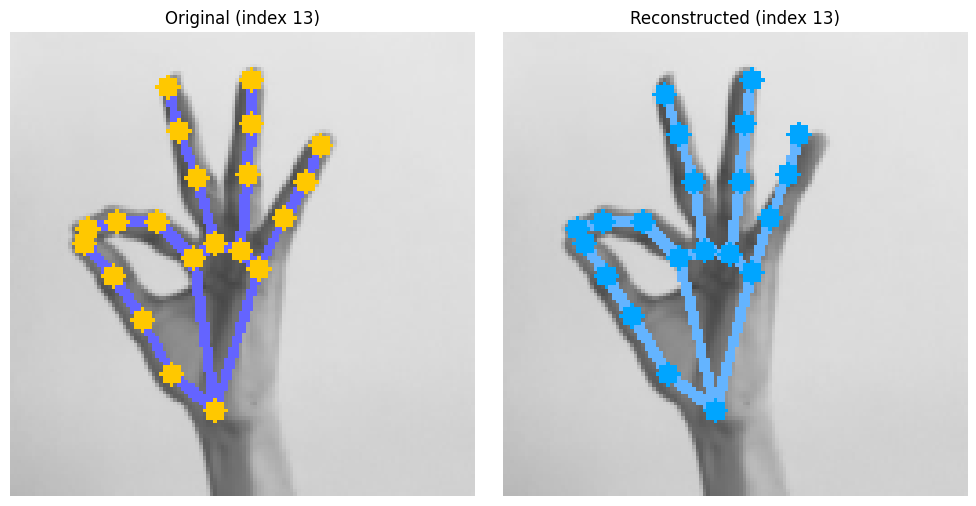

In [5]:
idx = 13  # change this to view another sample from the batch
model_kp.eval()
with torch.no_grad():
    data_img, _ = next(iter(val_loader_img))
    data_kp, _ = next(iter(val_loader_kp))
    data_kp = data_kp.to(device)
    recon_kp = model_kp(data_kp)
image_sample = data_img[idx]  # same sample as data_kp[idx] (loaders share order)
# 1) Raw image with keypoints overlaid (original left, reconstructed right)
plot_hand_keypoints_on_image(
    image_sample,
    data_kp[idx].cpu().numpy(),
    recon_kp[idx].cpu().numpy(),
    title_left=f"Original (index {idx})",
    title_right=f"Reconstructed (index {idx})",
)
# (3D interactive plot removed; use 2D overlay only)

#### Latent space clustering (keypoint AE)

Encode the validation set with the keypoint AE and scatter latent codes (t-SNE if dim > 2), colored by letter.

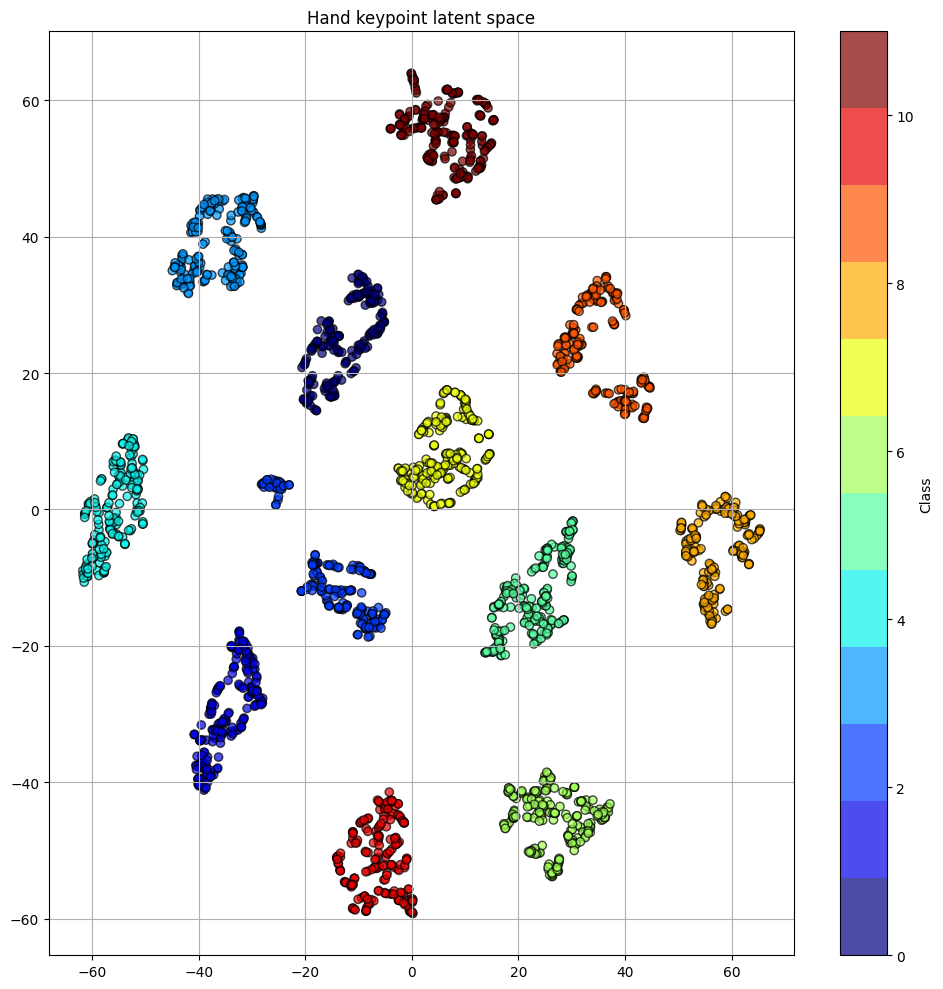

In [6]:
model_kp.eval()
latents_kp, labels_kp = [], []
with torch.no_grad():
    for data, lbl in val_loader_kp:
        data = data.to(device)
        z = model_kp.encode(data)
        latents_kp.append(z.cpu().numpy())
        labels_kp.append(lbl.numpy())
latents_kp = np.concatenate(latents_kp, axis=0)
labels_kp = np.concatenate(labels_kp, axis=0)
scatter_latent(latents_kp, labels_kp, title="Hand keypoint latent space")